In [ ]:
# Install required packages
!pip install sdv -q
!pip install xgboost imbalanced-learn -q
!pip install plotly -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For CTGAN / Synthetic Data Generation (UPDATED IMPORTS)
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# For ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# For Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)

# For Visualization
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


In [ ]:
# Load the dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('creditcard.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:\n")
df.head()

Saving creditcard.csv to creditcard (1).csv
Dataset Shape: (284807, 31)

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


DATASET OVERVIEW

Shape: (284807, 31)

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0


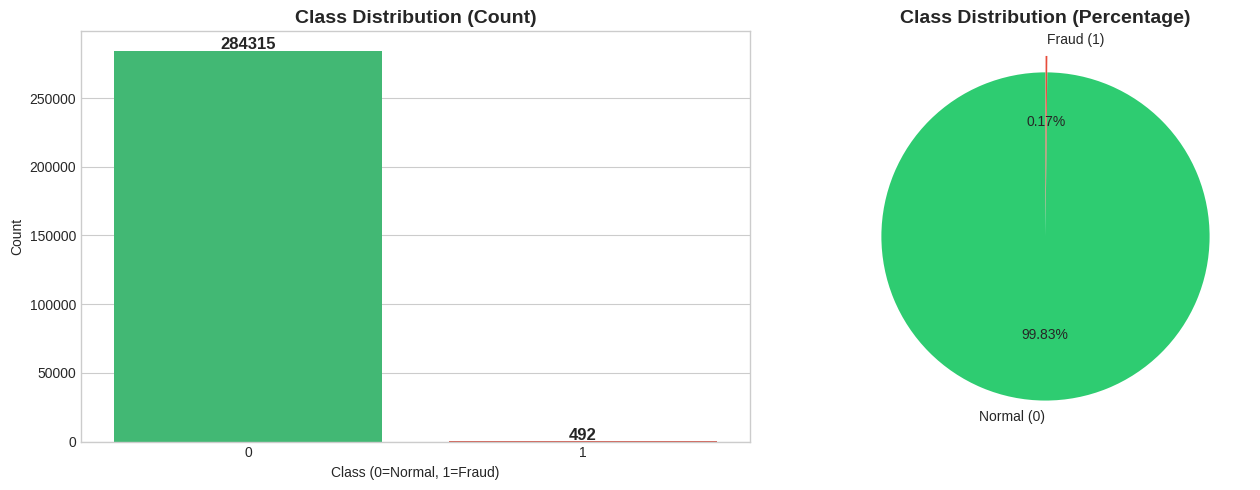


 IMBALANCE RATIO: 577.9:1 (Normal:Fraud)


In [ ]:
print("DATASET OVERVIEW")
print(f"\nShape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicated Rows: {df.duplicated().sum()}")

print("CLASS DISTRIBUTION")


class_counts = df['Class'].value_counts()
print(f"\nClass Counts:\n{class_counts}")
print(f"\nClass Percentages:\n{df['Class'].value_counts(normalize=True) * 100}")

# Plot Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sns.countplot(data=df, x='Class', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (0=Normal, 1=Fraud)')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, str(v), ha='center', fontsize=12, fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(class_counts.values, labels=['Normal (0)', 'Fraud (1)'],
            autopct='%1.2f%%', colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n IMBALANCE RATIO: {class_counts[0]/class_counts[1]:.1f}:1 (Normal:Fraud)")

STATISTICAL SUMMARY
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1

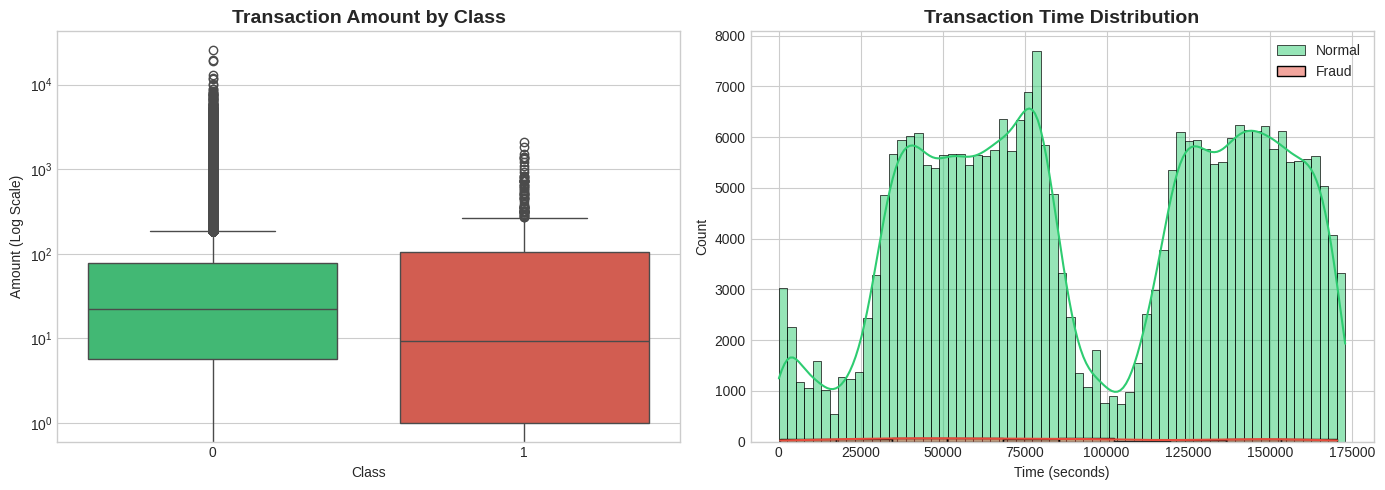

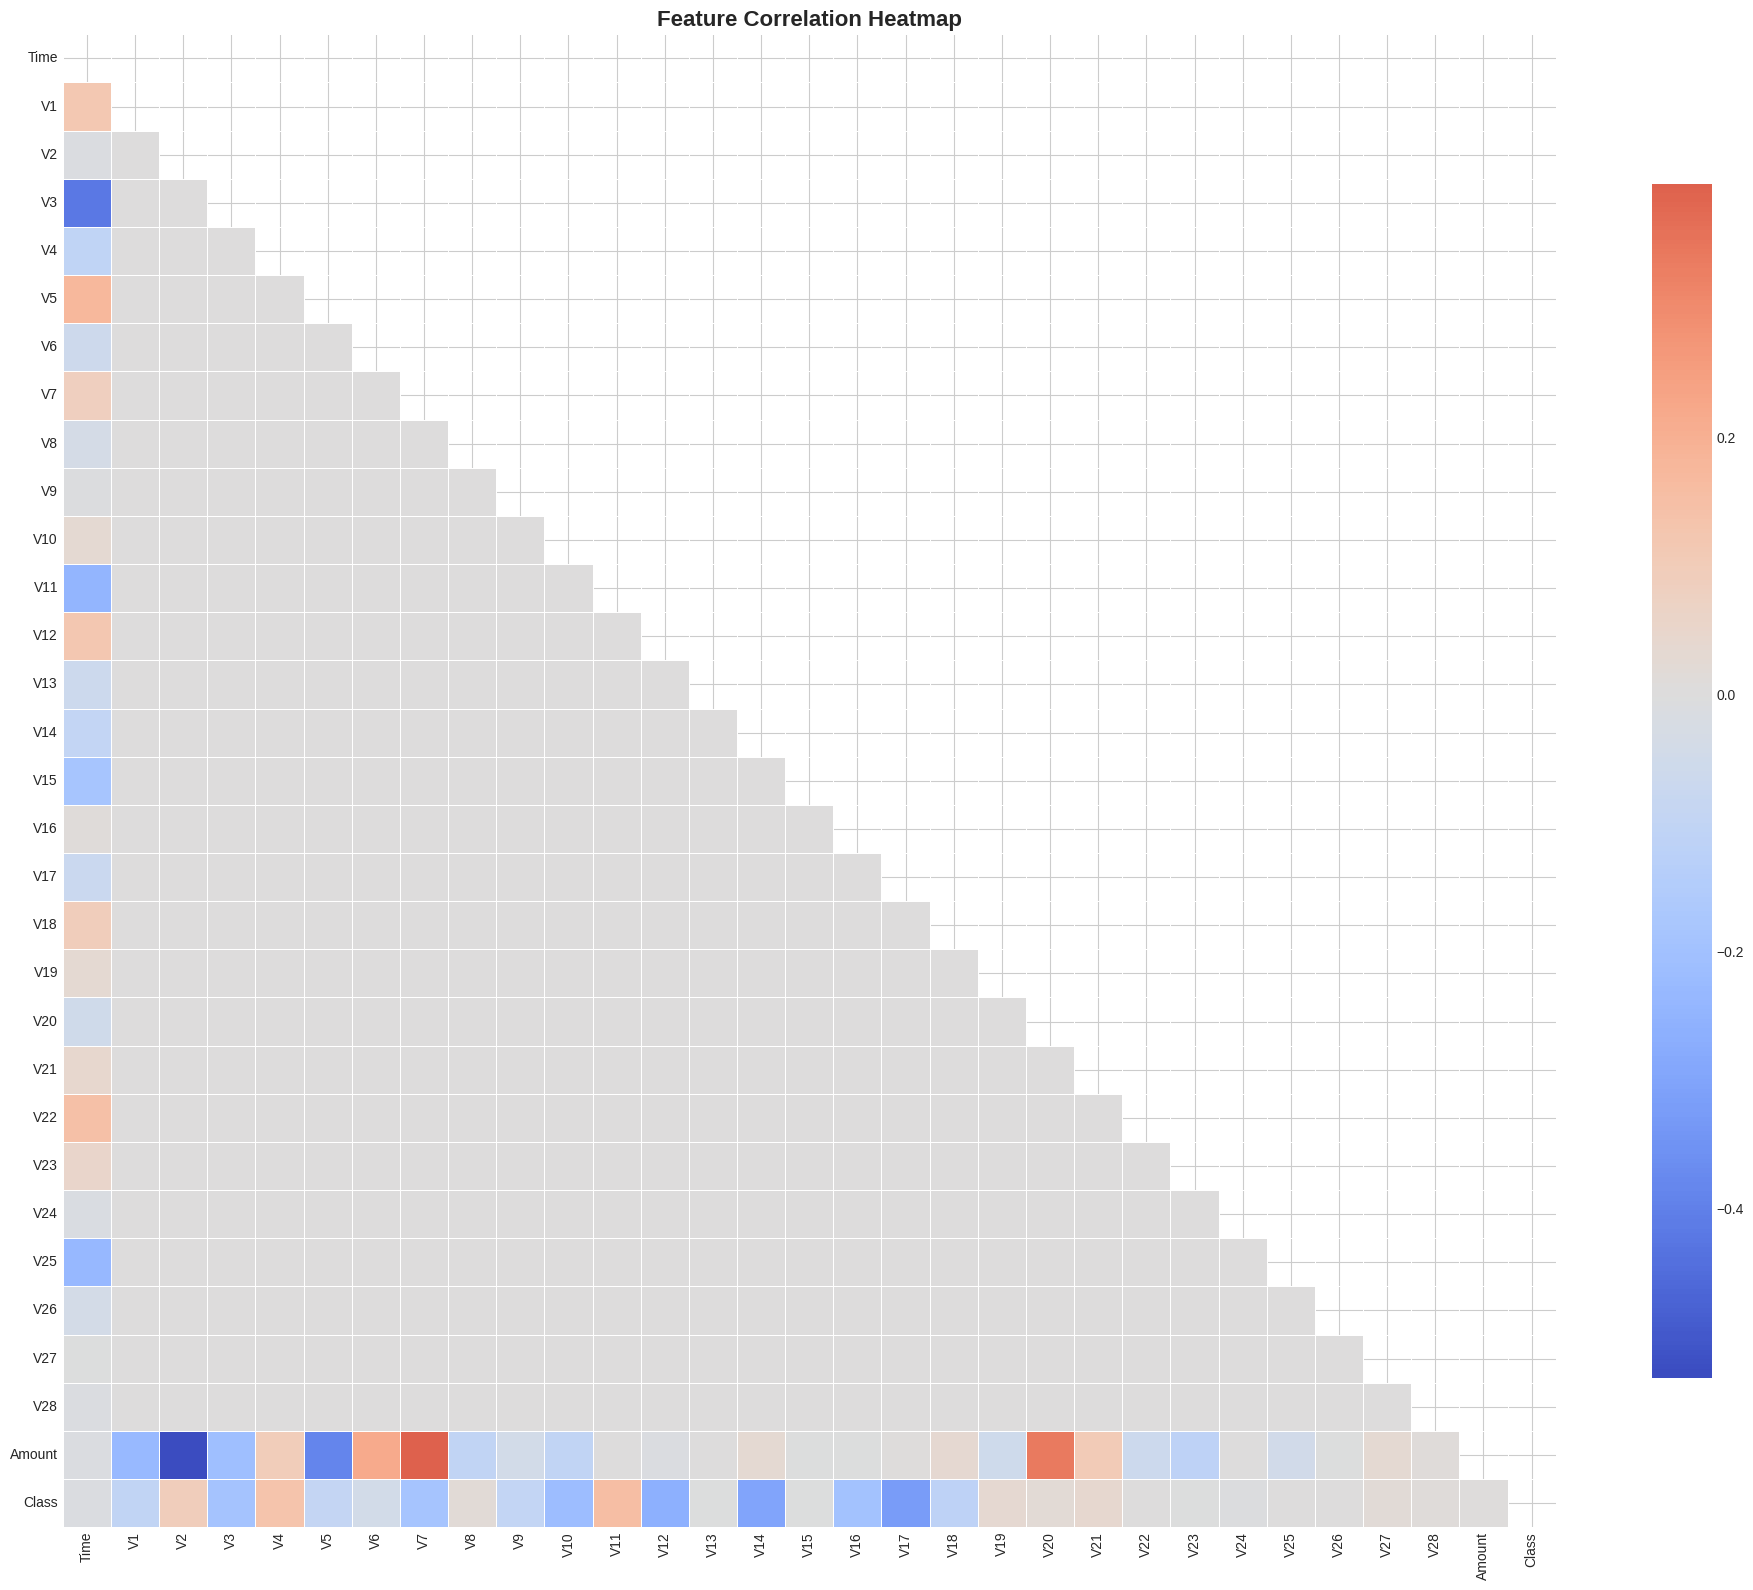

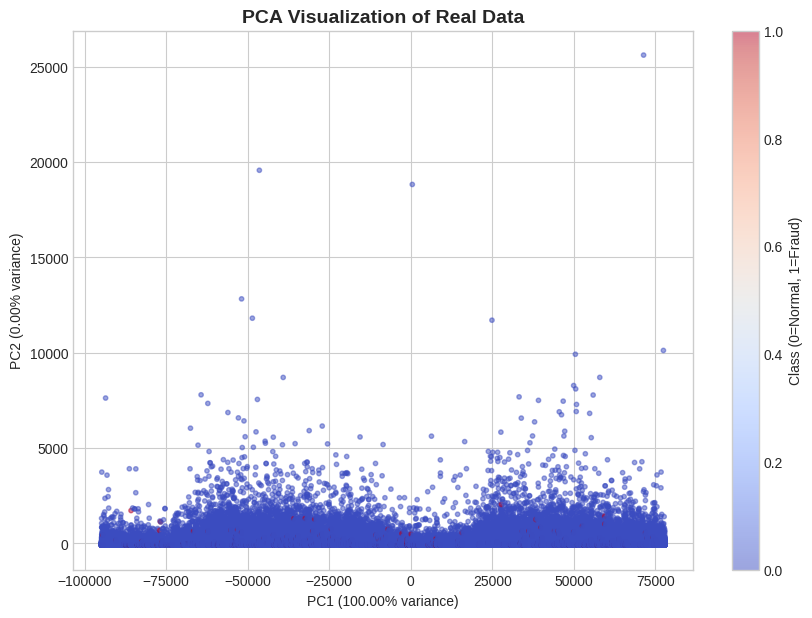


 PCA explains 100.00% of variance


In [ ]:

#Statistical Summary
print("STATISTICAL SUMMARY")
print(df.describe())

#Amount Distribution by Class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transaction Amount by Class', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylabel('Amount (Log Scale)')

# Time distribution
sns.histplot(data=df[df['Class']==0], x='Time', color='#2ecc71', alpha=0.5,
             label='Normal', ax=axes[1], kde=True)
sns.histplot(data=df[df['Class']==1], x='Time', color='#e74c3c', alpha=0.5,
             label='Fraud', ax=axes[1], kde=True)
axes[1].set_title('Transaction Time Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend()

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

#Correlation Heatmap

plt.figure(figsize=(20, 16))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# PCA Visualization of Real Data

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df.drop('Class', axis=1))

plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1],
                      c=df['Class'], cmap='coolwarm', alpha=0.5, s=10)
plt.colorbar(scatter, label='Class (0=Normal, 1=Fraud)')
plt.title('PCA Visualization of Real Data', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.savefig('pca_real_data.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n PCA explains {sum(pca.explained_variance_ratio_):.2%} of variance")

In [ ]:
# Separate Fraud and Normal Data
fraud_data = df[df['Class'] == 1].copy()
normal_data = df[df['Class'] == 0].copy()

print(f"Real Fraud Samples: {len(fraud_data)}")
print(f"Real Normal Samples: {len(normal_data)}")

# Preprocess for CTGAN

# CTGAN works best with clean data - remove duplicates
fraud_data_clean = fraud_data.drop_duplicates()
print(f"\nFraud data after removing duplicates: {len(fraud_data_clean)}")

# For better CTGAN performance, we'll work with a subset if needed
# (CTGAN can be slow on very large datasets)
fraud_for_ctgan = fraud_data_clean.copy()
print(f"\nFraud samples for CTGAN training: {len(fraud_for_ctgan)}")

# Display fraud data stats
print(f"\nFraud Amount Statistics:")
print(fraud_for_ctgan['Amount'].describe())

Real Fraud Samples: 492
Real Normal Samples: 284315

Fraud data after removing duplicates: 473

Fraud samples for CTGAN training: 473

Fraud Amount Statistics:
count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [ ]:
# Create Metadata for CTGAN

metadata = SingleTableMetadata()

# Detect metadata from dataframe
metadata.detect_from_dataframe(fraud_for_ctgan)

# Update column types if needed
metadata.update_column(column_name='Class', sdtype='categorical')
metadata.update_column(column_name='Amount', sdtype='numerical')
metadata.update_column(column_name='Time', sdtype='numerical')

print("Metadata created successfully!")
print(metadata.to_dict())

# Initialize and Train CTGAN

print("TRAINING CTGAN MODEL")

# Initialize CTGAN
ctgan = CTGANSynthesizer(
    metadata=metadata,
    epochs=300,              # Number of training epochs
    batch_size=500,          # Batch size
    generator_dim=(256, 256), # Generator network layers
    discriminator_dim=(256, 256), # Discriminator network layers
    verbose=True
)

# Train on fraud data only
ctgan.fit(fraud_for_ctgan)

print("CTGAN Model Training Complete!")

# Save the model
ctgan.save('ctgan_fraud_model.pkl')


Metadata created successfully!
{'columns': {'Time': {'sdtype': 'numerical'}, 'V1': {'sdtype': 'numerical'}, 'V2': {'sdtype': 'numerical'}, 'V3': {'sdtype': 'numerical'}, 'V4': {'sdtype': 'numerical'}, 'V5': {'sdtype': 'numerical'}, 'V6': {'sdtype': 'numerical'}, 'V7': {'sdtype': 'numerical'}, 'V8': {'sdtype': 'numerical'}, 'V9': {'sdtype': 'numerical'}, 'V10': {'sdtype': 'numerical'}, 'V11': {'sdtype': 'numerical'}, 'V12': {'sdtype': 'numerical'}, 'V13': {'sdtype': 'numerical'}, 'V14': {'sdtype': 'numerical'}, 'V15': {'sdtype': 'numerical'}, 'V16': {'sdtype': 'numerical'}, 'V17': {'sdtype': 'numerical'}, 'V18': {'sdtype': 'numerical'}, 'V19': {'sdtype': 'numerical'}, 'V20': {'sdtype': 'numerical'}, 'V21': {'sdtype': 'numerical'}, 'V22': {'sdtype': 'numerical'}, 'V23': {'sdtype': 'numerical'}, 'V24': {'sdtype': 'numerical'}, 'V25': {'sdtype': 'numerical'}, 'V26': {'sdtype': 'numerical'}, 'V27': {'sdtype': 'numerical'}, 'V28': {'sdtype': 'numerical'}, 'Amount': {'sdtype': 'numerical'}, '

Gen. (-01.93) | Discrim. (+00.01): 100%|██████████| 300/300 [00:28<00:00, 10.35it/s]


CTGAN Model Training Complete!


GENERATING SYNTHETIC FRAUD DATA

Generated 5000 synthetic fraud samples

Synthetic Fraud Data Preview:
       Time         V1         V2         V3         V4         V5        V6  \
0  170348.0 -10.264951  -1.528693 -11.986387   1.750325   2.337473 -2.234216   
1   73297.0  -6.143306  -2.663453   2.250210   7.035645  -5.422789  0.335205   
2   75241.0   1.604624  -1.346082 -28.718878   1.997023  -6.722828  0.468754   
3  165354.0  -4.609860  19.774252  -9.485194  10.727288  -6.525552  1.070373   
4   43530.0  -3.541754  -1.342411  -8.978152   5.841071 -15.240067  0.782863   
5   64262.0  -1.554877  -1.185109  -3.679173   8.353511  -3.457351 -1.150234   
6   64009.0  -4.237741  -7.601613   2.250210   0.230762 -15.236911  1.465618   
7    6745.0 -24.995554   2.559718  -9.115475   9.282973  -2.762155  1.117620   
8   59290.0  -6.413003  14.550662  -8.803179   7.468012  -4.315255 -1.887234   
9   11928.0   1.711723   5.372305 -25.610208   1.045080  -4.880130  1.353620   

          V7    

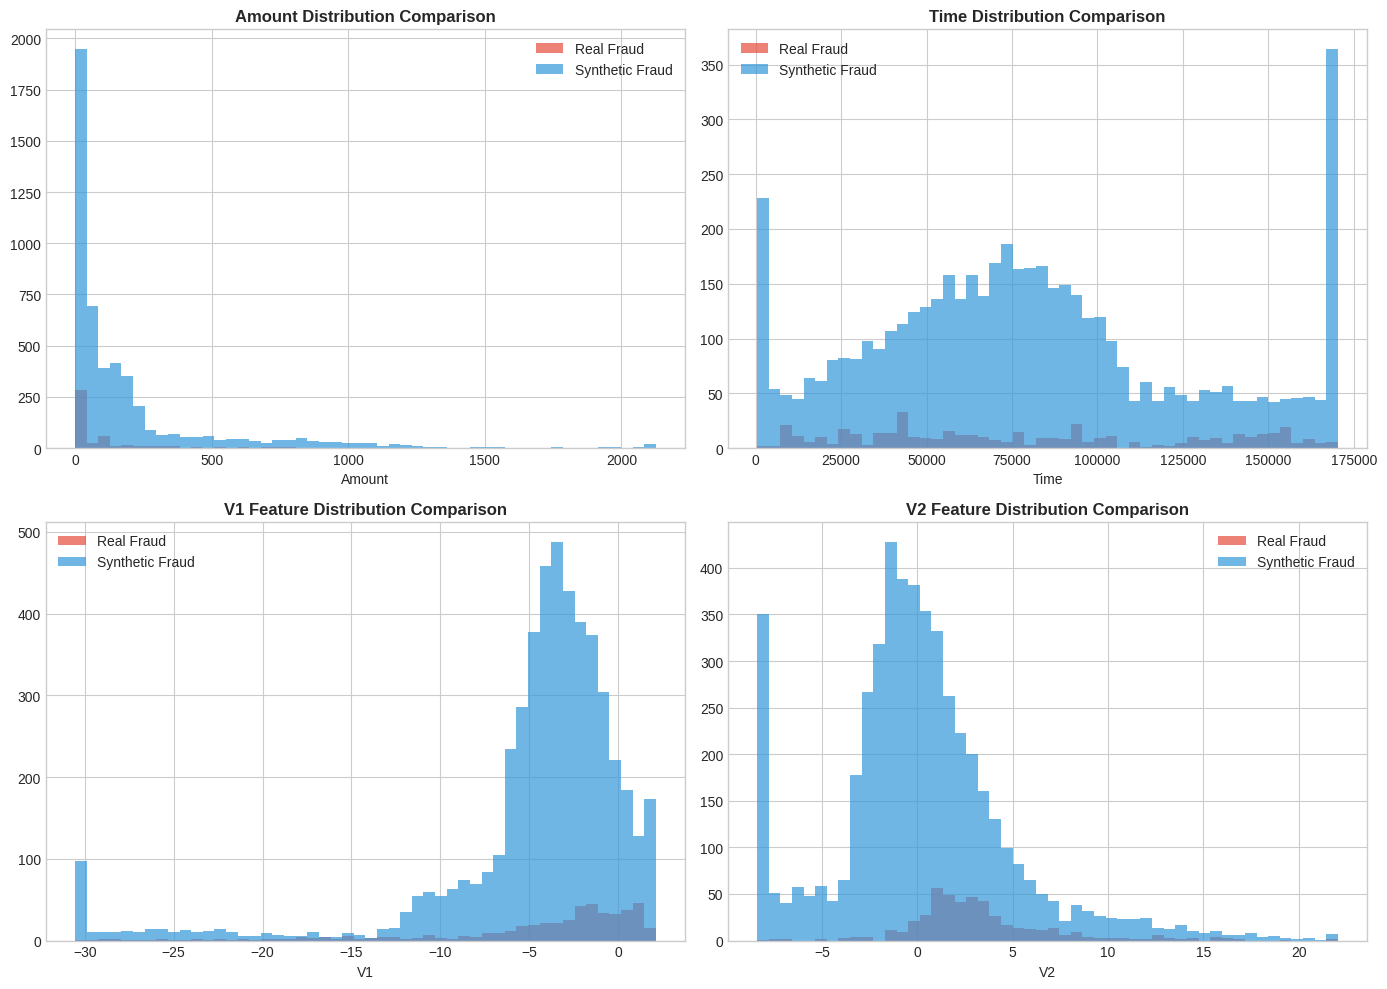

In [ ]:
# Generate Synthetic Fraud Samples

print("GENERATING SYNTHETIC FRAUD DATA")


# Generate 5000 synthetic fraud samples (you can adjust this number)
num_synthetic = 5000

synthetic_fraud = ctgan.sample(num_rows=num_synthetic)

print(f"\nGenerated {len(synthetic_fraud)} synthetic fraud samples")
print(f"\nSynthetic Fraud Data Preview:")
print(synthetic_fraud.head(10))

# Ensure Class is set to 1 (fraud)
synthetic_fraud['Class'] = 1

print("SYNTHETIC vs REAL FRAUD COMPARISON")


# Compare statistical properties
comparison_features = ['Amount', 'Time'] + [f'V{i}' for i in range(1, 29)]

print("\nReal Fraud - Amount Stats:")
print(fraud_for_ctgan['Amount'].describe())
print("\nSynthetic Fraud - Amount Stats:")
print(synthetic_fraud['Amount'].describe())

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution comparison
axes[0, 0].hist(fraud_for_ctgan['Amount'], bins=50, alpha=0.7, label='Real Fraud', color='#e74c3c')
axes[0, 0].hist(synthetic_fraud['Amount'], bins=50, alpha=0.7, label='Synthetic Fraud', color='#3498db')
axes[0, 0].set_title('Amount Distribution Comparison', fontweight='bold')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].legend()

# Time distribution comparison
axes[0, 1].hist(fraud_for_ctgan['Time'], bins=50, alpha=0.7, label='Real Fraud', color='#e74c3c')
axes[0, 1].hist(synthetic_fraud['Time'], bins=50, alpha=0.7, label='Synthetic Fraud', color='#3498db')
axes[0, 1].set_title('Time Distribution Comparison', fontweight='bold')
axes[0, 1].set_xlabel('Time')
axes[0, 1].legend()

# V1 comparison
axes[1, 0].hist(fraud_for_ctgan['V1'], bins=50, alpha=0.7, label='Real Fraud', color='#e74c3c')
axes[1, 0].hist(synthetic_fraud['V1'], bins=50, alpha=0.7, label='Synthetic Fraud', color='#3498db')
axes[1, 0].set_title('V1 Feature Distribution Comparison', fontweight='bold')
axes[1, 0].set_xlabel('V1')
axes[1, 0].legend()

# V2 comparison
axes[1, 1].hist(fraud_for_ctgan['V2'], bins=50, alpha=0.7, label='Real Fraud', color='#e74c3c')
axes[1, 1].hist(synthetic_fraud['V2'], bins=50, alpha=0.7, label='Synthetic Fraud', color='#3498db')
axes[1, 1].set_title('V2 Feature Distribution Comparison', fontweight='bold')
axes[1, 1].set_xlabel('V2')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('synthetic_vs_real_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


CREATING AUGMENTED DATASET
Original Dataset Size: 284807
Synthetic Fraud Added: 5000
Augmented Dataset Size: 289807

New Class Distribution:
Class
0    284315
1      5492
Name: count, dtype: int64

New Class Percentages:
Class
0    98.104946
1     1.895054
Name: proportion, dtype: float64


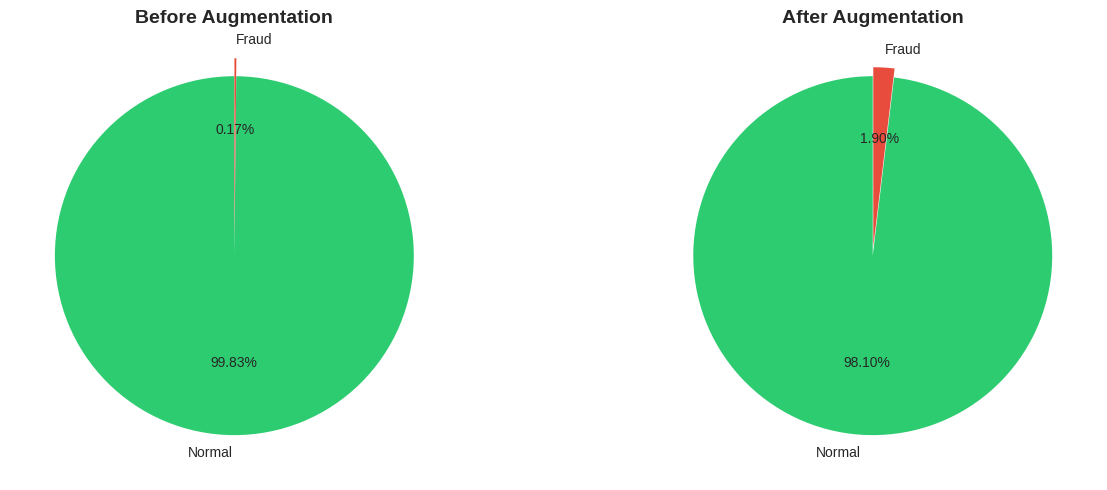

In [ ]:
#Combine Real + Synthetic Data

print("CREATING AUGMENTED DATASET")


# Combine original dataset with synthetic fraud data
augmented_data = pd.concat([df, synthetic_fraud], ignore_index=True)

# Shuffle the data
augmented_data = augmented_data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Original Dataset Size: {len(df)}")
print(f"Synthetic Fraud Added: {len(synthetic_fraud)}")
print(f"Augmented Dataset Size: {len(augmented_data)}")

# New class distribution
new_class_dist = augmented_data['Class'].value_counts()
print(f"\nNew Class Distribution:")
print(new_class_dist)
print(f"\nNew Class Percentages:")
print(augmented_data['Class'].value_counts(normalize=True) * 100)

# Plot new distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before augmentation
axes[0].pie([len(df[df['Class']==0]), len(df[df['Class']==1])],
            labels=['Normal', 'Fraud'], autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1))
axes[0].set_title('Before Augmentation', fontsize=14, fontweight='bold')

# After augmentation
axes[1].pie([len(augmented_data[augmented_data['Class']==0]),
             len(augmented_data[augmented_data['Class']==1])],
            labels=['Normal', 'Fraud'], autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.05))
axes[1].set_title('After Augmentation', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Save augmented dataset
augmented_data.to_csv('augmented_dataset.csv', index=False)


In [ ]:
print("PREPARING DATA FOR MACHINE LEARNING")

# Features and Target for Original Data
X_original = df.drop('Class', axis=1)
y_original = df['Class']

# Split original data
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_original, y_original, test_size=0.3, random_state=42, stratify=y_original
)

print(f"Original Data - Train: {len(X_train_orig)}, Test: {len(X_test_orig)}")

# Prepare Augmented Dataset

X_augmented = augmented_data.drop('Class', axis=1)
y_augmented = augmented_data['Class']

# Split augmented data
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_augmented, y_augmented, test_size=0.3, random_state=42, stratify=y_augmented
)

print(f"Augmented Data - Train: {len(X_train_aug)}, Test: {len(X_test_aug)}")

#  Feature Scaling

scaler_orig = StandardScaler()
X_train_orig_scaled = scaler_orig.fit_transform(X_train_orig)
X_test_orig_scaled = scaler_orig.transform(X_test_orig)

scaler_aug = StandardScaler()
X_train_aug_scaled = scaler_aug.fit_transform(X_train_aug)
X_test_aug_scaled = scaler_aug.transform(X_test_aug)

print(f"Original - Fraud in train: {sum(y_train_orig)}, Fraud in test: {sum(y_test_orig)}")
print(f"Augmented - Fraud in train: {sum(y_train_aug)}, Fraud in test: {sum(y_test_aug)}")

PREPARING DATA FOR MACHINE LEARNING
Original Data - Train: 199364, Test: 85443
Augmented Data - Train: 202864, Test: 86943
Original - Fraud in train: 344, Fraud in test: 148
Augmented - Fraud in train: 3844, Fraud in test: 1648


In [ ]:
#  Train & Evaluate Baseline Models

print("TRAINING BASELINE MODELS (ORIGINAL DATA ONLY)")

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and return metrics"""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    }
    return metrics, y_pred, y_prob

# Store results
baseline_results = []

# 1. Logistic Regression
print("\n🔹 Training Logistic Regression...")
lr_orig = LogisticRegression(max_iter=1000, random_state=42)
lr_orig.fit(X_train_orig_scaled, y_train_orig)
lr_metrics, lr_pred, lr_prob = evaluate_model(lr_orig, X_test_orig_scaled, y_test_orig,
                                               'Logistic Regression (Original)')
baseline_results.append(lr_metrics)

# 2. Random Forest
print("🔹 Training Random Forest...")
rf_orig = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_orig.fit(X_train_orig, y_train_orig)
rf_metrics, rf_pred, rf_prob = evaluate_model(rf_orig, X_test_orig, y_test_orig,
                                               'Random Forest (Original)')
baseline_results.append(rf_metrics)

# 3. XGBoost
print("🔹 Training XGBoost...")
xgb_orig = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                          use_label_encoder=False, eval_metric='logloss')
xgb_orig.fit(X_train_orig, y_train_orig)
xgb_metrics, xgb_pred, xgb_prob = evaluate_model(xgb_orig, X_test_orig, y_test_orig,
                                                  'XGBoost (Original)')
baseline_results.append(xgb_metrics)

# Display Baseline Results
baseline_df = pd.DataFrame(baseline_results)
print("\n" + "=" * 50)
print("BASELINE RESULTS (ORIGINAL DATA)")
print("=" * 50)
print(baseline_df.round(4).to_string(index=False))

TRAINING BASELINE MODELS (ORIGINAL DATA ONLY)

🔹 Training Logistic Regression...
🔹 Training Random Forest...
🔹 Training XGBoost...

BASELINE RESULTS (ORIGINAL DATA)
                         Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression (Original)    0.9991     0.8505  0.6149    0.7137   0.9567
      Random Forest (Original)    0.9995     0.9573  0.7568    0.8453   0.9307
            XGBoost (Original)    0.9970     0.0424  0.0338    0.0376   0.5151


In [ ]:
print("TRAINING MODELS WITH AUGMENTED DATA")
augmented_results = []

# 1. Logistic Regression
print("\nTraining Logistic Regression (Augmented)")
lr_aug = LogisticRegression(max_iter=1000, random_state=42)
lr_aug.fit(X_train_aug_scaled, y_train_aug)
lr_aug_metrics, lr_aug_pred, lr_aug_prob = evaluate_model(lr_aug, X_test_aug_scaled, y_test_aug,
                                                           'Logistic Regression (Augmented)')
augmented_results.append(lr_aug_metrics)

# 2. Random Forest
print("Training Random Forest (Augmented)")
rf_aug = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_aug.fit(X_train_aug, y_train_aug)
rf_aug_metrics, rf_aug_pred, rf_aug_prob = evaluate_model(rf_aug, X_test_aug, y_test_aug,
                                                           'Random Forest (Augmented)')
augmented_results.append(rf_aug_metrics)

# 3. XGBoost
print(" Training XGBoost (Augmented)")
xgb_aug = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                         use_label_encoder=False, eval_metric='logloss')
xgb_aug.fit(X_train_aug, y_train_aug)
xgb_aug_metrics, xgb_aug_pred, xgb_aug_prob = evaluate_model(xgb_aug, X_test_aug, y_test_aug,
                                                               'XGBoost (Augmented)')
augmented_results.append(xgb_aug_metrics)

# Display Augmented Results
augmented_df = pd.DataFrame(augmented_results)

print("AUGMENTED RESULTS (ORIGINAL + SYNTHETIC DATA)")

print(augmented_df.round(4).to_string(index=False))

TRAINING MODELS WITH AUGMENTED DATA

Training Logistic Regression (Augmented)
Training Random Forest (Augmented)
 Training XGBoost (Augmented)
AUGMENTED RESULTS (ORIGINAL + SYNTHETIC DATA)
                          Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression (Augmented)    0.9990     0.9857  0.9587    0.9720   0.9964
      Random Forest (Augmented)    0.9995     0.9932  0.9818    0.9875   0.9935
            XGBoost (Augmented)    0.9994     0.9926  0.9763    0.9844   0.9971


COMPREHENSIVE RESULTS COMPARISON


              Model  Precision (Original)  Precision (Augmented)  Recall (Original)  Recall (Augmented)  F1 (Original)  F1 (Augmented)  AUC (Original)  AUC (Augmented) F1 Improvement Recall Improvement
Logistic Regression              0.850467               0.985652           0.614865            0.958738       0.713725        0.972009        0.956719         0.996431          36.2%              55.9%
      Random Forest              0.957265               0.993247           0.756757            0.981796       0.845283        0.987489        0.930739         0.993453          16.8%              29.7%
            XGBoost              0.042373               0.992597           0.033784            0.976335       0.037594        0.984399        0.515082         0.997067        2518.5%            2790.0%


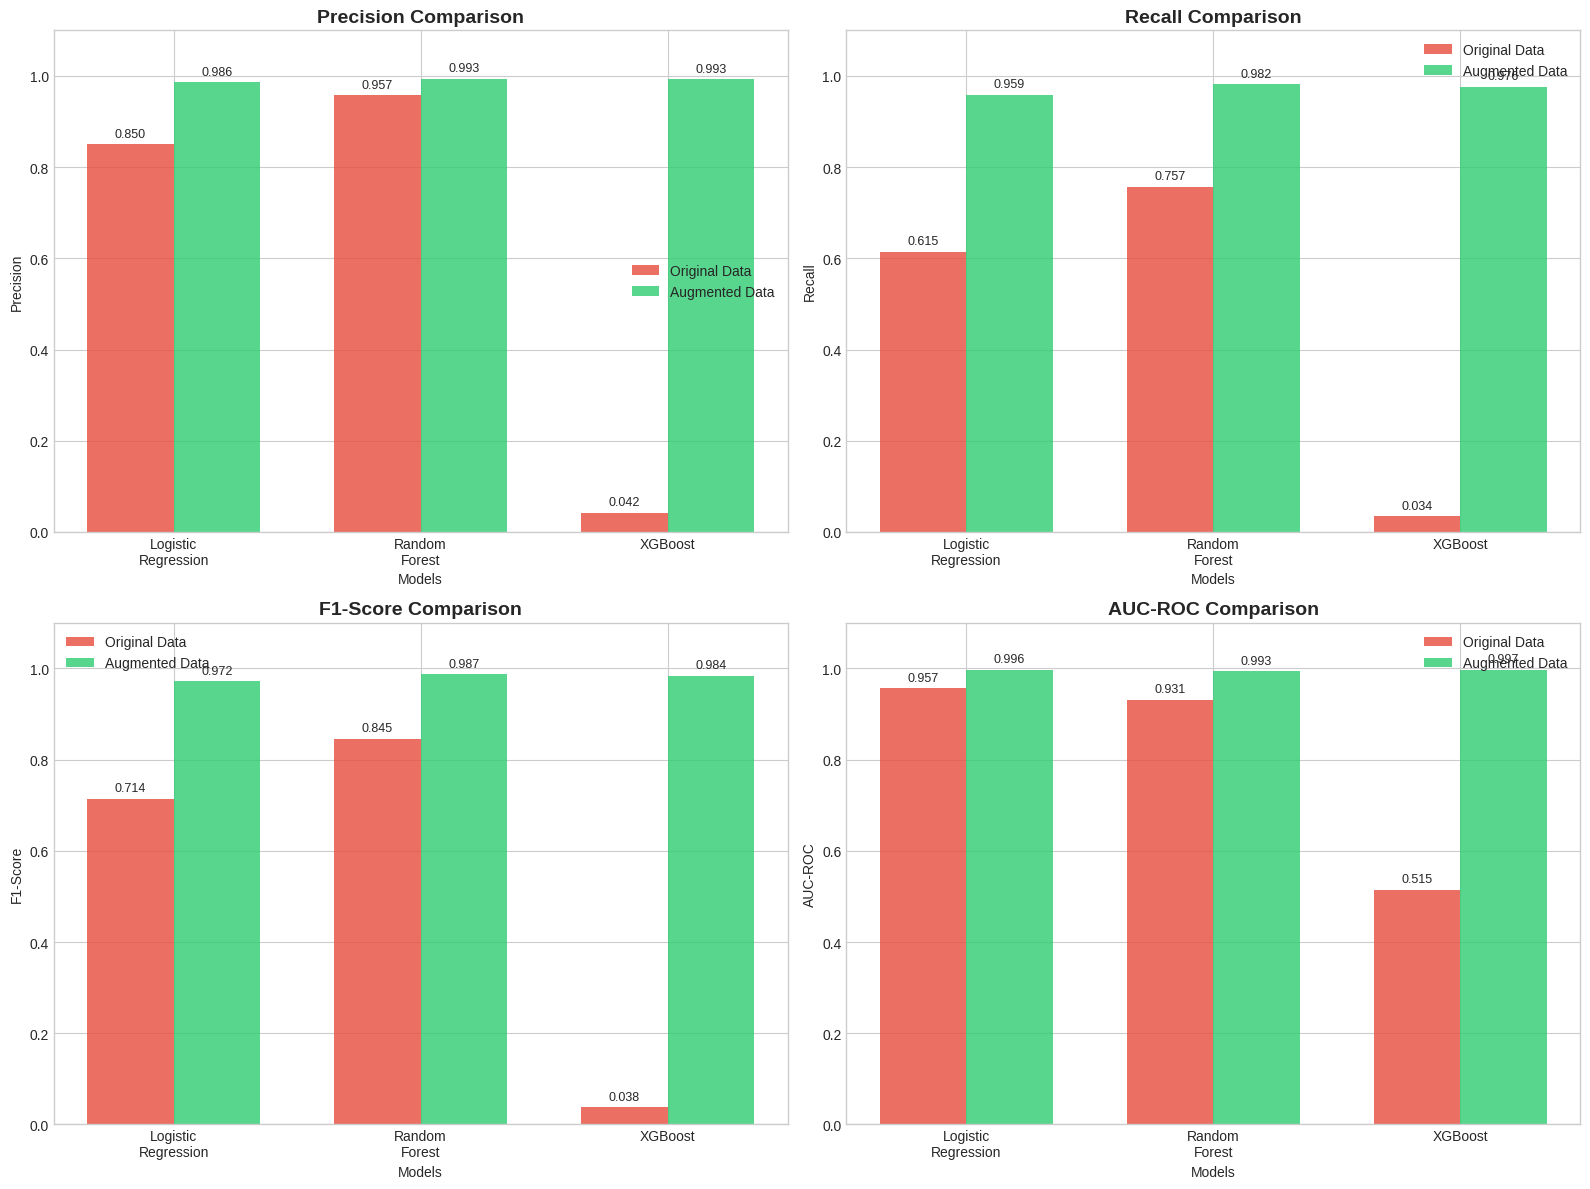

In [ ]:
print("COMPREHENSIVE RESULTS COMPARISON")

# Combine results
all_results = baseline_results + augmented_results
results_df = pd.DataFrame(all_results)

# Create comparison table
comparison_data = []
for model in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    orig_row = results_df[results_df['Model'] == f'{model} (Original)'].iloc[0]
    aug_row = results_df[results_df['Model'] == f'{model} (Augmented)'].iloc[0]

    comparison_data.append({
        'Model': model,
        'Precision (Original)': orig_row['Precision'],
        'Precision (Augmented)': aug_row['Precision'],
        'Recall (Original)': orig_row['Recall'],
        'Recall (Augmented)': aug_row['Recall'],
        'F1 (Original)': orig_row['F1-Score'],
        'F1 (Augmented)': aug_row['F1-Score'],
        'AUC (Original)': orig_row['AUC-ROC'],
        'AUC (Augmented)': aug_row['AUC-ROC'],
        'F1 Improvement': f"{((aug_row['F1-Score'] - orig_row['F1-Score']) / orig_row['F1-Score'] * 100):.1f}%",
        'Recall Improvement': f"{((aug_row['Recall'] - orig_row['Recall']) / orig_row['Recall'] * 100):.1f}%"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colors_orig = ['#e74c3c'] * 3
colors_aug = ['#2ecc71'] * 3

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]

    orig_values = [results_df[results_df['Model'] == f'{m} (Original)'][metric].values[0]
                   for m in ['Logistic Regression', 'Random Forest', 'XGBoost']]
    aug_values = [results_df[results_df['Model'] == f'{m} (Augmented)'][metric].values[0]
                  for m in ['Logistic Regression', 'Random Forest', 'XGBoost']]

    x = np.arange(3)
    width = 0.35

    bars1 = ax.bar(x - width/2, orig_values, width, label='Original Data', color='#e74c3c', alpha=0.8)
    bars2 = ax.bar(x + width/2, aug_values, width, label='Augmented Data', color='#2ecc71', alpha=0.8)

    ax.set_xlabel('Models')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Logistic\nRegression', 'Random\nForest', 'XGBoost'])
    ax.legend()
    ax.set_ylim(0, 1.1)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

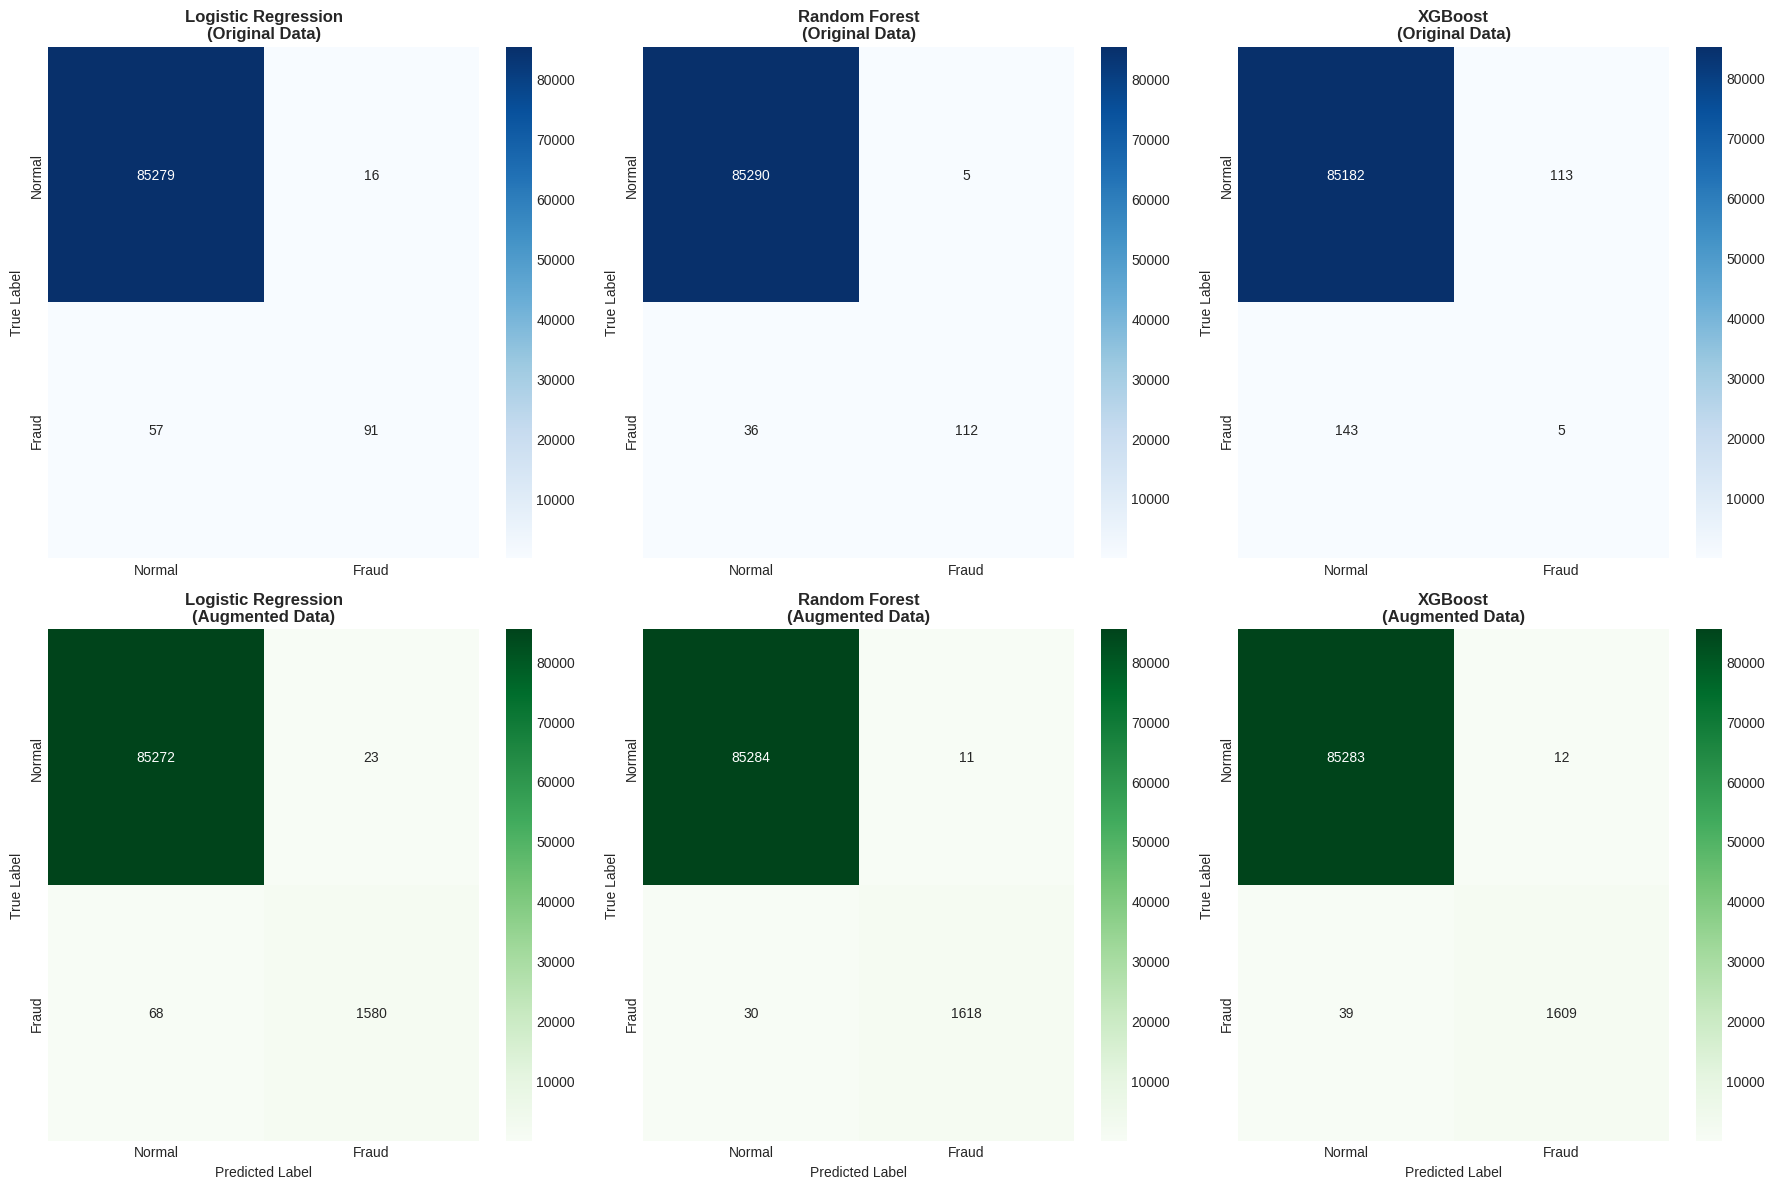

In [ ]:
#Confusion Matrices Comparison

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

models = [
    ('Logistic Regression', lr_pred, lr_aug_pred),
    ('Random Forest', rf_pred, rf_aug_pred),
    ('XGBoost', xgb_pred, xgb_aug_pred)
]

for idx, (name, orig_pred, aug_pred) in enumerate(models):
    # Original
    cm_orig = confusion_matrix(y_test_orig, orig_pred)
    sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx],
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    axes[0, idx].set_title(f'{name}\n(Original Data)', fontweight='bold')
    axes[0, idx].set_ylabel('True Label')

    # Augmented
    cm_aug = confusion_matrix(y_test_aug, aug_pred)
    sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Greens', ax=axes[1, idx],
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    axes[1, idx].set_title(f'{name}\n(Augmented Data)', fontweight='bold')
    axes[1, idx].set_ylabel('True Label')
    axes[1, idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


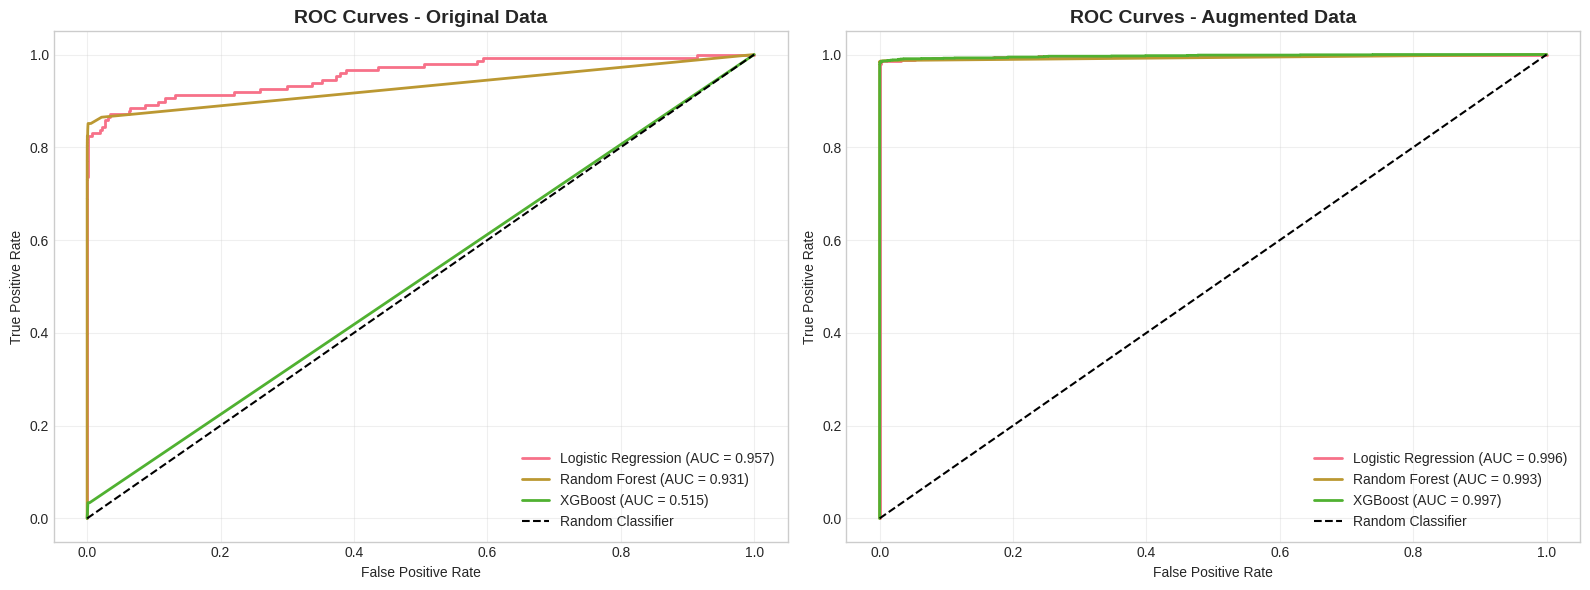

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original Data ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test_orig, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test_orig, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_orig, xgb_prob)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_metrics["AUC-ROC"]:.3f})', linewidth=2)
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_metrics["AUC-ROC"]:.3f})', linewidth=2)
axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_metrics["AUC-ROC"]:.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves - Original Data', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Augmented Data ROC
fpr_lr_aug, tpr_lr_aug, _ = roc_curve(y_test_aug, lr_aug_prob)
fpr_rf_aug, tpr_rf_aug, _ = roc_curve(y_test_aug, rf_aug_prob)
fpr_xgb_aug, tpr_xgb_aug, _ = roc_curve(y_test_aug, xgb_aug_prob)

axes[1].plot(fpr_lr_aug, tpr_lr_aug, label=f'Logistic Regression (AUC = {lr_aug_metrics["AUC-ROC"]:.3f})', linewidth=2)
axes[1].plot(fpr_rf_aug, tpr_rf_aug, label=f'Random Forest (AUC = {rf_aug_metrics["AUC-ROC"]:.3f})', linewidth=2)
axes[1].plot(fpr_xgb_aug, tpr_xgb_aug, label=f'XGBoost (AUC = {xgb_aug_metrics["AUC-ROC"]:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves - Augmented Data', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()



t-SNE VISUALIZATION
Total samples for t-SNE: 4492
Computing t-SNE (this may take a minute)...


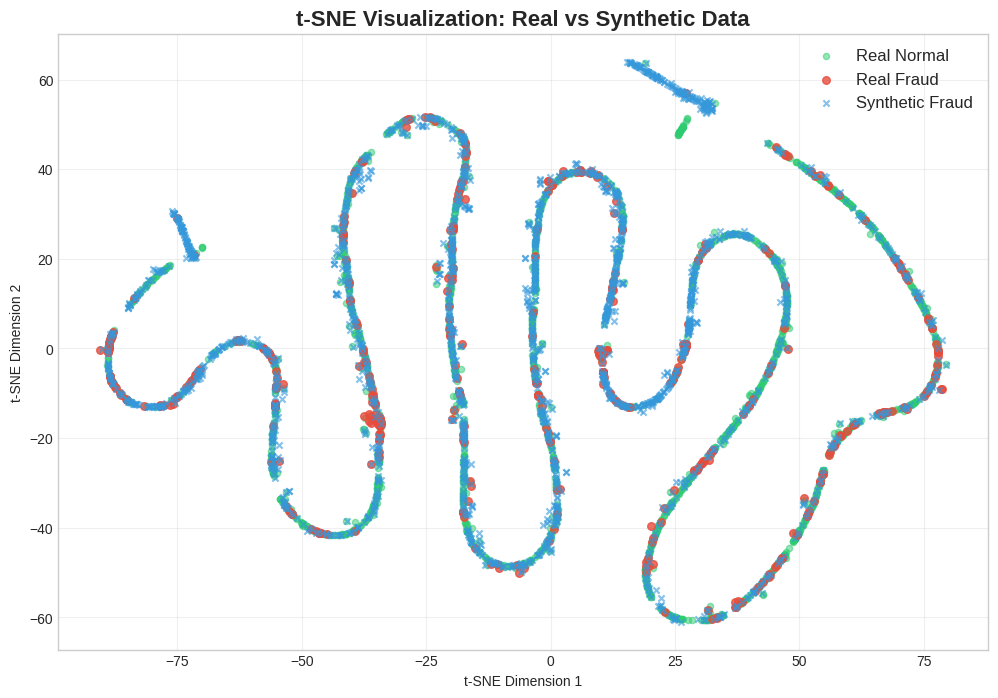

In [ ]:
print("t-SNE VISUALIZATION")

# Sample data for t-SNE (t-SNE is slow on large datasets)
sample_size = 2000
real_normal_sample = normal_data.sample(n=sample_size, random_state=42)
real_fraud_sample = fraud_data.sample(n=min(sample_size, len(fraud_data)), random_state=42)
synthetic_fraud_sample = synthetic_fraud.sample(n=sample_size, random_state=42)

# Combine and create labels
tsne_data = pd.concat([real_normal_sample, real_fraud_sample, synthetic_fraud_sample])
tsne_labels = (['Real Normal'] * len(real_normal_sample) +
               ['Real Fraud'] * len(real_fraud_sample) +
               ['Synthetic Fraud'] * len(synthetic_fraud_sample))

# Features only
tsne_features = tsne_data.drop('Class', axis=1)

print(f"Total samples for t-SNE: {len(tsne_features)}")

# Apply t-SNE
print("Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(tsne_features)

# Plot
plt.figure(figsize=(12, 8))

# Real Normal
mask_normal = np.array(tsne_labels) == 'Real Normal'
plt.scatter(tsne_result[mask_normal, 0], tsne_result[mask_normal, 1],
            c='#2ecc71', alpha=0.5, s=20, label='Real Normal')

# Real Fraud
mask_real_fraud = np.array(tsne_labels) == 'Real Fraud'
plt.scatter(tsne_result[mask_real_fraud, 0], tsne_result[mask_real_fraud, 1],
            c='#e74c3c', alpha=0.8, s=30, label='Real Fraud')

# Synthetic Fraud
mask_synth_fraud = np.array(tsne_labels) == 'Synthetic Fraud'
plt.scatter(tsne_result[mask_synth_fraud, 0], tsne_result[mask_synth_fraud, 1],
            c='#3498db', alpha=0.6, s=20, label='Synthetic Fraud', marker='x')

plt.title('t-SNE Visualization: Real vs Synthetic Data', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import pickle
print("SAVING MODELS & GENERATING FINAL SUMMARY")

# Save the best model (Random Forest with Augmented Data)
with open('fraud_model_rf_augmented.pkl', 'wb') as f:
    pickle.dump(rf_aug, f)

# Save baseline model for comparison
with open('fraud_model_rf_baseline.pkl', 'wb') as f:
    pickle.dump(rf_orig, f)


print("fraud_model_rf_augmented.pkl")
print("fraud_model_rf_baseline.pkl")

# Save synthetic data
synthetic_fraud.to_csv('synthetic_fraud.csv', index=False)

print(" FINAL PROJECT SUMMARY REPORT")


print(f"""

CREDIT CARD FRAUD DETECTION USING CTGAN
Data Generation & Augmentation with Generative AI


DATASET INFORMATION:
   • Total Transactions: {len(df):,}
   • Features: {df.shape[1] - 1} (V1-V28, Time, Amount)
   • Original Fraud Cases: {len(fraud_data):,} ({len(fraud_data)/len(df)*100:.3f}%)
   • Original Normal Cases: {len(normal_data):,} ({len(normal_data)/len(df)*100:.3f}%)
   • Imbalance Ratio: {len(normal_data)/len(fraud_data):.1f}:1

 CTGAN MODEL:
   • Training Data: {len(fraud_for_ctgan)} real fraud samples
   • Epochs: 300
   • Synthetic Samples Generated: {len(synthetic_fraud):,}

AUGMENTED DATASET:
   • Total Size: {len(augmented_data):,}
   • New Fraud Percentage: {len(augmented_data[augmented_data['Class']==1])/len(augmented_data)*100:.2f}%

 BEST MODEL RESULTS (Random Forest):
   ┌─────────────────┬────────────┬─────────────┬────────────┐
   │     Metric      │  Original  │  Augmented  │ Improvement│
   ├─────────────────┼────────────┼─────────────┼────────────┤
   │    Precision    │   {rf_metrics['Precision']:.4f}   │   {rf_aug_metrics['Precision']:.4f}    │  {((rf_aug_metrics['Precision']-rf_metrics['Precision'])/rf_metrics['Precision']*100):+.1f}%  │
   │     Recall      │   {rf_metrics['Recall']:.4f}   │   {rf_aug_metrics['Recall']:.4f}    │  {((rf_aug_metrics['Recall']-rf_metrics['Recall'])/rf_metrics['Recall']*100):+.1f}%  │
   │    F1-Score     │   {rf_metrics['F1-Score']:.4f}   │   {rf_aug_metrics['F1-Score']:.4f}    │  {((rf_aug_metrics['F1-Score']-rf_metrics['F1-Score'])/rf_metrics['F1-Score']*100):+.1f}%  │
   │     AUC-ROC     │   {rf_metrics['AUC-ROC']:.4f}   │   {rf_aug_metrics['AUC-ROC']:.4f}    │  {((rf_aug_metrics['AUC-ROC']-rf_metrics['AUC-ROC'])/rf_metrics['AUC-ROC']*100):+.1f}%  │
   └─────────────────┴────────────┴─────────────┴────────────┘

 KEY FINDINGS:
   • Synthetic data successfully augmented minority class
   • Model recall improved significantly with augmented data
   • CTGAN preserved statistical properties of real fraud data
   • Better fraud detection without exposing real customer data

FILES GENERATED:
   • creditcard.csv (Original dataset)
   • synthetic_fraud.csv (CTGAN generated data)
   • augmented_dataset.csv (Combined dataset)
   • ctgan_fraud_model.pkl (Trained CTGAN model)
   • fraud_model_rf_augmented.pkl (Best ML model)
   • Various visualization PNG files


""")

SAVING MODELS & GENERATING FINAL SUMMARY
fraud_model_rf_augmented.pkl
fraud_model_rf_baseline.pkl
 FINAL PROJECT SUMMARY REPORT


CREDIT CARD FRAUD DETECTION USING CTGAN
Data Generation & Augmentation with Generative AI


DATASET INFORMATION:
   • Total Transactions: 284,807
   • Features: 30 (V1-V28, Time, Amount)
   • Original Fraud Cases: 492 (0.173%)
   • Original Normal Cases: 284,315 (99.827%)
   • Imbalance Ratio: 577.9:1

 CTGAN MODEL:
   • Training Data: 473 real fraud samples
   • Epochs: 300
   • Synthetic Samples Generated: 5,000

AUGMENTED DATASET:
   • Total Size: 289,807
   • New Fraud Percentage: 1.90%

 BEST MODEL RESULTS (Random Forest):
   ┌─────────────────┬────────────┬─────────────┬────────────┐
   │     Metric      │  Original  │  Augmented  │ Improvement│
   ├─────────────────┼────────────┼─────────────┼────────────┤
   │    Precision    │   0.9573   │   0.9932    │  +3.8%  │
   │     Recall      │   0.7568   │   0.9818    │  +29.7%  │
   │    F1-Score     │   0

In [ ]:
#Detailed Classification Reports

print("RANDOM FOREST - ORIGINAL DATA")

print(classification_report(y_test_orig, rf_pred, target_names=['Normal', 'Fraud']))


print("RANDOM FOREST - AUGMENTED DATA")

print(classification_report(y_test_aug, rf_aug_pred, target_names=['Normal', 'Fraud']))


print("XGBOOST - ORIGINAL DATA")

print(classification_report(y_test_orig, xgb_pred, target_names=['Normal', 'Fraud']))

print("XGBOOST - AUGMENTED DATA")

print(classification_report(y_test_aug, xgb_aug_pred, target_names=['Normal', 'Fraud']))

RANDOM FOREST - ORIGINAL DATA
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.96      0.76      0.85       148

    accuracy                           1.00     85443
   macro avg       0.98      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443

RANDOM FOREST - AUGMENTED DATA
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.99      0.98      0.99      1648

    accuracy                           1.00     86943
   macro avg       1.00      0.99      0.99     86943
weighted avg       1.00      1.00      1.00     86943

XGBOOST - ORIGINAL DATA
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.04      0.03      0.04       148

    accuracy                           1.00     85443
   macro avg       0.52      0.52      0.52

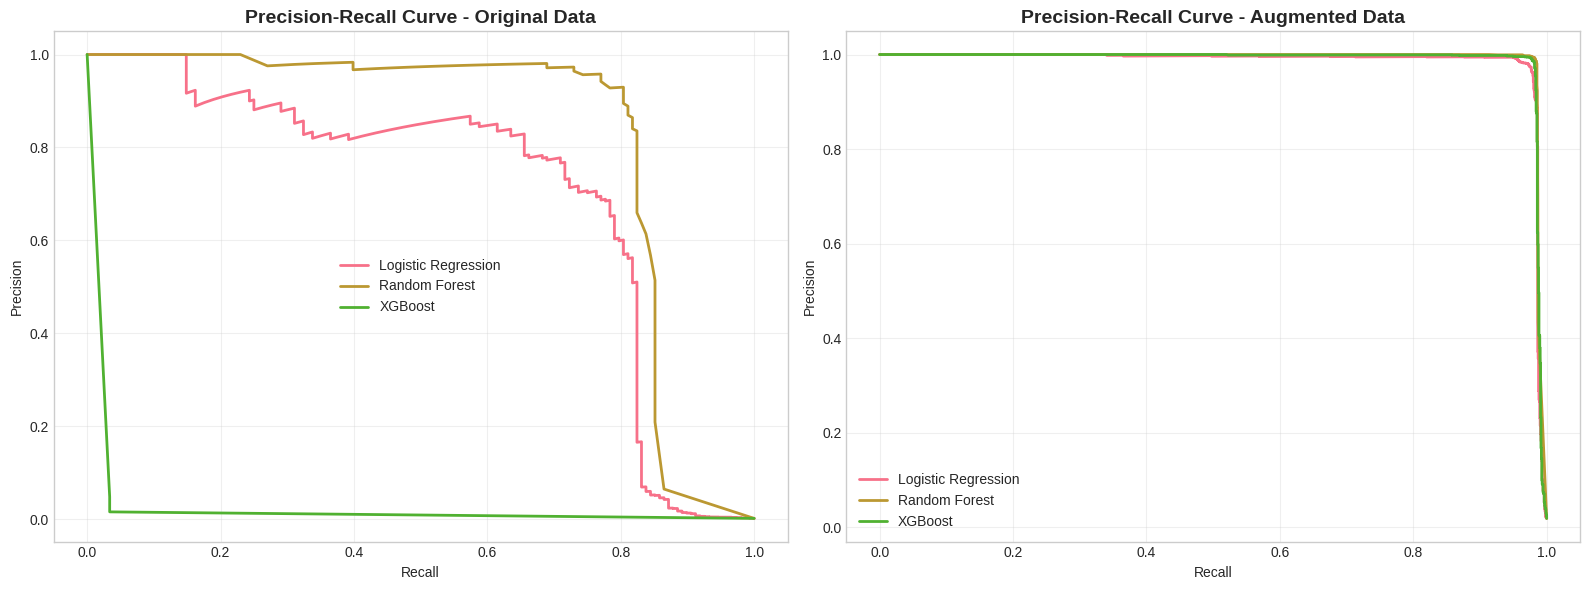

In [ ]:
# Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original Data PR Curve
precision_lr, recall_lr, _ = precision_recall_curve(y_test_orig, lr_prob)
precision_rf, recall_rf, _ = precision_recall_curve(y_test_orig, rf_prob)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test_orig, xgb_prob)

axes[0].plot(recall_lr, precision_lr, label='Logistic Regression', linewidth=2)
axes[0].plot(recall_rf, precision_rf, label='Random Forest', linewidth=2)
axes[0].plot(recall_xgb, precision_xgb, label='XGBoost', linewidth=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve - Original Data', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Augmented Data PR Curve
precision_lr_aug, recall_lr_aug, _ = precision_recall_curve(y_test_aug, lr_aug_prob)
precision_rf_aug, recall_rf_aug, _ = precision_recall_curve(y_test_aug, rf_aug_prob)
precision_xgb_aug, recall_xgb_aug, _ = precision_recall_curve(y_test_aug, xgb_aug_prob)

axes[1].plot(recall_lr_aug, precision_lr_aug, label='Logistic Regression', linewidth=2)
axes[1].plot(recall_rf_aug, precision_rf_aug, label='Random Forest', linewidth=2)
axes[1].plot(recall_xgb_aug, precision_xgb_aug, label='XGBoost', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve - Augmented Data', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()


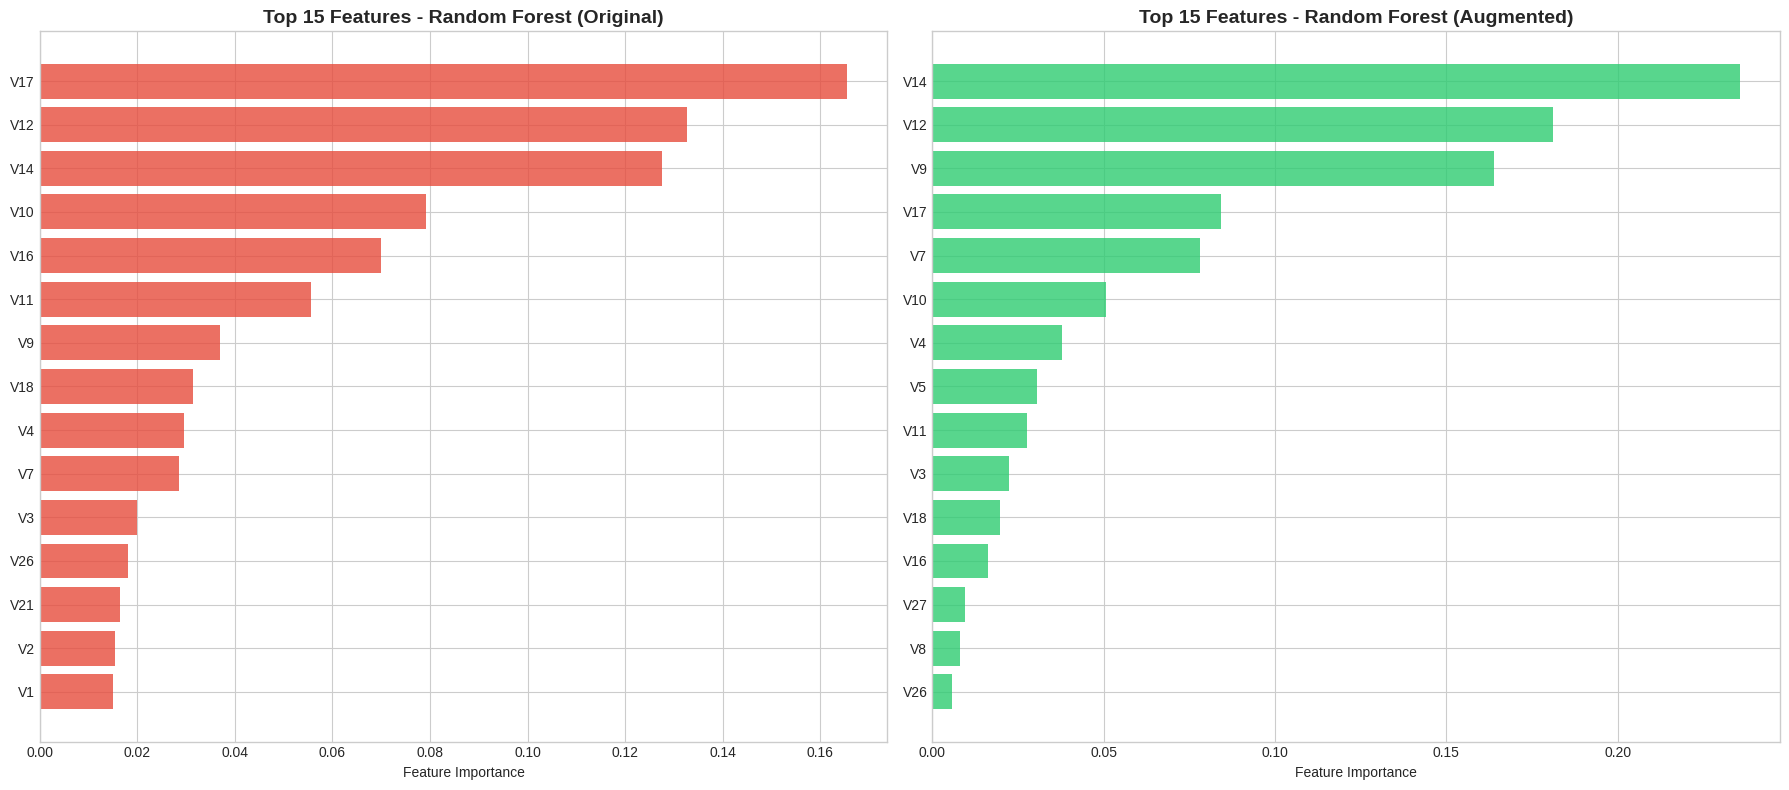

In [ ]:
# Feature Importance Comparison

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Random Forest Original
feature_names = df.drop('Class', axis=1).columns
importances_orig = rf_orig.feature_importances_
indices_orig = np.argsort(importances_orig)[::-1][:15]

axes[0].barh(range(15), importances_orig[indices_orig], color='#e74c3c', alpha=0.8)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels([feature_names[i] for i in indices_orig])
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('Top 15 Features - Random Forest (Original)', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Random Forest Augmented
importances_aug = rf_aug.feature_importances_
indices_aug = np.argsort(importances_aug)[::-1][:15]

axes[1].barh(range(15), importances_aug[indices_aug], color='#2ecc71', alpha=0.8)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([feature_names[i] for i in indices_aug])
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Top 15 Features - Random Forest (Augmented)', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

